### Langchain version v1

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

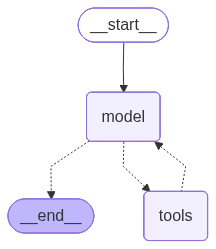

In [4]:
from langchain.agents import create_agent

def get_weather(city:str) -> str:
    """Get the weather for a city."""
    return f"The weather in {city} is sunny."

agent = create_agent(
    model="gpt-5",
    tools=[get_weather],
    system_prompt="You are a helpful assistant"
)
agent

In [7]:
### run the agent
# agent.invoke({"messages":[{"role":"user", "content":"What is the weather like in New York?"}]})

In [6]:
import langchain
langchain.__version__

'1.3.11'

### Models Integration with openAi, Gemini and groq

In [8]:
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [ ]:
from langchain.chat_models import init_chat_model

model = init_chat_model("llama-3.3-70b-versatile",
model_provider="groq"
)

model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001983A02A270>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001983A02A7B0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [23]:
response = model.invoke("Hello How are you?")
response.content

"Hello. I'm just a language model, so I don't have emotions or feelings like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?"

### Google Gemini model Integration

In [26]:
model1 = init_chat_model("google_genai:gemini-2.5-flash-lite")
response = model1.invoke("Why do parrots talk?")
response.content

'Parrots talk for a variety of reasons, and it\'s a fascinating aspect of their intelligence and social nature. Here\'s a breakdown of the main drivers:\n\n**1. Social Bonding and Communication:**\n\n*   **Flock Mentality:** Parrots are highly social creatures in the wild. They live in flocks and rely on constant communication to stay together, warn of danger, find food, and maintain social hierarchies. Mimicking sounds, including those of their flock mates and other animals, is a crucial part of this communication.\n*   **Establishing and Maintaining Relationships:** In a flock, vocalizations help individuals recognize each other, build bonds, and reinforce social structures. By imitating sounds, a parrot can signal its presence, acknowledge others, and participate in the group\'s "conversations."\n\n**2. Intelligence and Cognitive Abilities:**\n\n*   **Impressive Mimicry Skills:** Parrots possess a highly developed syrinx (their vocal organ) and a complex brain that allows them to le

In [30]:
from langchain_groq import ChatGroq

model = ChatGroq(model="llama-3.3-70b-versatile")
response = model.invoke("Helo How are you?")
response

AIMessage(content="Hello, I'm doing well, thank you for asking. It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 41, 'total_tokens': 76, 'completion_time': 0.075631574, 'completion_tokens_details': None, 'prompt_time': 0.001358029, 'prompt_tokens_details': None, 'queue_time': 0.055542131, 'total_time': 0.076989603}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0fef-6c90-7fd3-a8ed-e418b928b181-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 35, 'total_tokens': 76})

### Streaming and Batch

### Streaming
Most models can stream their output content while it id being generated. By displaying output progressively, streaming significantly improve user experience, particularly for longer response. calling stream() returns an iterator that yields output chunks as they are produced. You can use a loop to process each chunk in real time.

In [33]:
for chunk in model.stream("Write a paragraph on AI within 100 words"):
    print(chunk.text, end = " ", flush=True)


 Art ificial  Intelligence  ( AI )  refers  to  computer  systems  that  can  perform  tasks  that  typically  require  human  intelligence .  AI  enables  machines  to  learn ,  reason ,  and  interact  with  their  environment .  It  has  various  applications ,  including  virtual  assistants ,  language  translation ,  and  image  recognition .  AI  is  transforming  industries  and  revolution izing  the  way  we  live  and  work .  As  technology  advances ,  AI  is  becoming  increasingly  sophisticated ,  opening  up  new  possibilities  and  opportunities  for  innovation  and  growth .  Its  potential  is  vast  and  continues  to  expand .   

### Batch
Batching is a collection of independent requests to a model can significantly improve performance and reduce cost, as the processing can be done in parallel

In [36]:
responses = model.batch([
    "Why do parrots have colorful feathers?",
    "How do airplane fly",
    "What is quantum computing?"
])

for response in responses:
    print(response)

content='Parrots have colorful feathers for several reasons:\n\n1. **Mating and Attraction**: Bright, vibrant plumage helps parrots attract mates. The more colorful and impressive the feathers, the more attractive the parrot is to potential partners. This is especially true for male parrots, which often have more intense colors than females.\n2. **Communication and Expression**: Parrots use their colorful feathers to communicate with each other. They can display their feathers to signal aggression, courtship, or warning calls. For example, a parrot may spread its colorful tail feathers to signal dominance or attract a mate.\n3. **Camouflage and Defense**: Although it may seem counterintuitive, colorful feathers can also serve as camouflage in certain environments. For example, the bright greens and blues of some parrot species can help them blend in with the foliage of their tropical habitats. Additionally, some parrots have feathers with patterns that can distract or confuse predators